In [1]:
# ---------- Setup ----------
%load_ext autoreload
%autoreload 2
import sys, os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Verify that SimpleArm is in the path
SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
if SIMPLEARM_PATH not in sys.path:
    sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.robot import RobotInfo

# Import local functions
import models
from data import generate_dataset, print_dataset_stats, browse_dataset, visualize_environment
from losses import compute_trajectory_collision_cost, compute_trajectory_joint_limits_cost
from utils import get_world_spheres_torch, query_sdf_differentiable
from training import train, train_env_autoencoder, train_state_autoencoder
from visualization import browse_trajectories

# Robot configuration
WORKSPACE_RADIUS = 1.0
LINK_LENGTHS = [0.35, 0.45, 0.2]
SPHERE_RAD = 0.08
GRID_LENGTH = 2.5
N_VOX = 128
T = 50  # Time steps in the trajectory
C = 10  # Control points in the spline
Q_MIN = np.array([-np.pi*0.9, -np.pi*0.9, -np.pi*0.9])
Q_MAX = np.array([np.pi*0.9, np.pi*0.9, np.pi*0.9])

robot = RobotInfo.from_linklengths(LINK_LENGTHS, sphere_rad=SPHERE_RAD)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Setup done. Executed in GPU: {gpu_name}")
else:
    print("Setup done. WARNING: Running on CPU. GPU not detected.")

Setup done. Executed in GPU: Tesla T4


Generating SDFs...


Generating SDF dataset:   0%|          | 0/20000 [00:00<?, ?it/s]

SDF dataset saved: data/sdf_dataset_0807.pt  shape=(20000, 1, 128, 128)


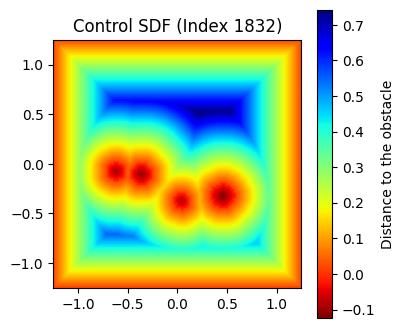

In [3]:
# ---------- SDF Dataset ----------
from data import generate_sdf_dataset

# Generate 20,000 environments for training the Autoencoder 
print("Generating SDFs...")
sdf_dataset = generate_sdf_dataset(N=20000, save_path="data/sdf_dataset_0807.pt", seed=42)

# Visual control
idx = torch.randint(0, len(sdf_dataset), (1,)).item()
plt.figure(figsize=(4, 4))
plt.imshow(sdf_dataset[idx, 0].cpu().numpy(), cmap="jet_r", origin="lower", 
           extent=[-GRID_LENGTH/2, GRID_LENGTH/2, -GRID_LENGTH/2, GRID_LENGTH/2])
plt.title(f"Control SDF (Index {idx})")
plt.colorbar(label="Distance to the obstacle")
plt.show()

Training the Environment Autoencoder...


Training Env Autoencoder:   0%|          | 0/8000 [00:00<?, ?it/s]

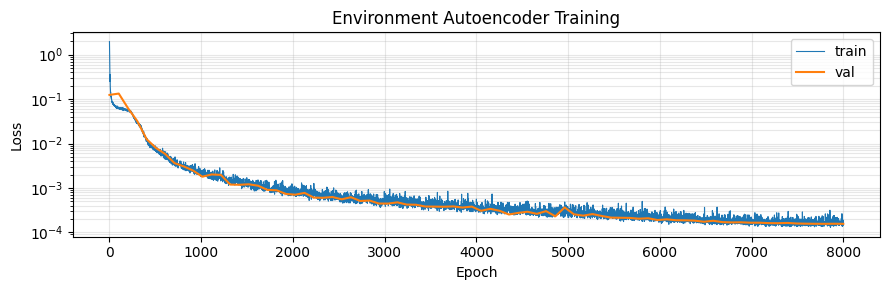

Test loss: 0.000160
Saved: data/env_autoencoder_0807.pt  (encoder -> data/env_encoder_0807.pt)
Weights saved in 'data/env_autoencoder_0807.pt'


In [5]:
# ---------- Environment Autoencoder Training ----------
print("Training the Environment Autoencoder...")

env_model, env_history = train_env_autoencoder(
    dataset_path = "data/sdf_dataset_0807.pt",
    file_name = "env_encoder_0807.pt",
    latent_dim   = 64,
    batch_size   = 128,                           
    epochs       = 8000,                          
    lr           = 1e-3,
    log_every    = 100,
    device       = device,
    save_path    = "data/env_autoencoder_0807.pt" 
)

print("Weights saved in 'data/env_autoencoder_0807.pt'")

Training State Autoencoder:   0%|          | 0/8000 [00:00<?, ?it/s]

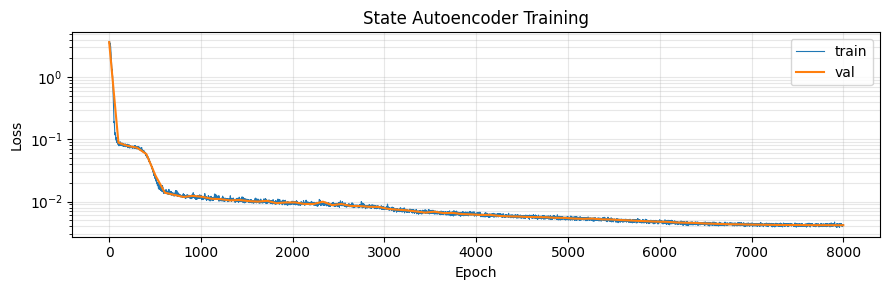

Test loss: 0.004188
Saved: data/state_autoencoder_0807.pt  (encoder -> data/state_encoder_0807.pt)
Weights saved in 'data/state_autoencoder_0807.pt'


In [6]:
# ---------- State Autoencoder Training ----------
from training import train_state_autoencoder
state_ae, state_ae_history = train_state_autoencoder(
    file_name   = "state_encoder_0807.pt",
    linklengths = LINK_LENGTHS,
    dof         = 3,
    latent_dim  = 12,
    N           = 240_000,
    batch_size  = 256,
    epochs      = 8000,
    lr          = 1e-3,
    log_every   = 100,
    device      = device,
    save_path   = "data/state_autoencoder_0807.pt"
)

print("Weights saved in 'data/state_autoencoder_0807.pt'")

In [15]:
# ---------- Dataset generation ----------
SEED = 42

# General Dataset
dataset_general_0807 = generate_dataset(
        N_envs            = 1000,
        pairs_per_env     = 10,
        robot             = robot,
        sphere_rad        = SPHERE_RAD,
        q_min             = Q_MIN,
        q_max             = Q_MAX,
        n_obstacles_range = (1, 3),
        r_range           = (0.06, 0.18),
        workspace_radius  = WORKSPACE_RADIUS,
        dist_from_origin  = (0.61, WORKSPACE_RADIUS),
        require_nontrivial= True,
        grid_length       = GRID_LENGTH,
        n_vox             = N_VOX,
        seed              = SEED,
        save_path         = "data/dataset_general_0807.pt",
        split             = (0.7, 0.15, 0.15)
        )

Generating dataset:   0%|          | 0/1000 [00:00<?, ?it/s]


────────────────────────────────────────────────
  Attempts:           10000
  No valid pair:      2
  Successful samples: 9998  (100.0%)
────────────────────────────────────────────────
  Saved: data/dataset_general_0807_train.pt  (6998 samples, 459.1 MB)
  Saved: data/dataset_general_0807_val.pt  (1499 samples, 98.3 MB)
  Saved: data/dataset_general_0807_test.pt  (1501 samples, 98.5 MB)


In [16]:
# ---------- Datasets analysis ----------
print("=== DATASETS - GENERAL STATISTICS ===")

print("\n1. General Dataset:")
print_dataset_stats("data/dataset_general_0807_train.pt")

print("\n" + "="*20 + " INTERACTIVE VISUALIZATION " + "="*20 + "\n")
interactive_dataset = torch.load("data/dataset_general_0807_train.pt", weights_only=False)
browse_dataset(interactive_dataset, grid_length=GRID_LENGTH)

=== DATASETS - GENERAL STATISTICS ===

1. General Dataset:
Dataset: 6998 samples
  sdf          (6998, 1, 128, 128)
  q_start      (6998, 3)
  q_goal       (6998, 3)
  obstacles    (6998, 3, 3)
  n_obstacles  (6998,)

Metadata: {'N': 6998, 'grid_length': 2.5, 'n_vox': 128, 'dof': 3, 'linklengths': [np.float64(0.35), np.float64(0.45), np.float64(0.2)], 'sphere_rad': 0.08, 'q_min': [-2.827433388230814, -2.827433388230814, -2.827433388230814], 'q_max': [2.827433388230814, 2.827433388230814, 2.827433388230814]}

Start-config collision rate (first 100 samples): mean=0.000  (should be ~0.0)

==================== INTERACTIVE VISUALIZATION ====================



Starting training...
Loaded env encoder:   data/env_encoder_0807.pt
Loaded state encoder: data/state_encoder_0807.pt

Loss              Raw      Weight    Weighted
──────────────────────────────────────────────
coll           2.3763    100.0000    237.6335
joints         0.0000      1.0000      0.0000
smooth         0.2016      2.0000      0.4031
spacing        0.0000      2.0000      0.0000
explore        0.3164      5.0000      1.5820



Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Epoch   200 | lr=4.97e-04 | train=7.7886  coll=6.9013  joints=0.1655  smooth=0.6733  spacing=0.0485  explore=0.0000  val=8.3395
Epoch   400 | lr=4.88e-04 | train=6.6925  coll=5.0667  joints=0.1531  smooth=1.3540  spacing=0.1187  explore=0.0000  val=6.2322
Epoch   600 | lr=4.73e-04 | train=4.8460  coll=2.8683  joints=0.0210  smooth=1.8456  spacing=0.1111  explore=0.0000  val=4.2110
Epoch   800 | lr=4.52e-04 | train=3.8567  coll=2.0781  joints=0.0070  smooth=1.6818  spacing=0.0844  explore=0.0055  val=3.9016
Epoch  1000 | lr=4.27e-04 | train=3.5056  coll=1.6676  joints=0.0243  smooth=1.7345  spacing=0.0791  explore=0.0000  val=3.8939
Epoch  1200 | lr=3.97e-04 | train=3.6624  coll=1.8312  joints=0.0060  smooth=1.7299  spacing=0.0946  explore=0.0007  val=3.7933
Epoch  1400 | lr=3.64e-04 | train=3.0167  coll=1.2412  joints=0.0090  smooth=1.6759  spacing=0.0906  explore=0.0000  val=3.7100
Epoch  1600 | lr=3.28e-04 | train=3.2635  coll=1.5694  joints=0.0052  smooth=1.6005  spacing=0.0884  exp

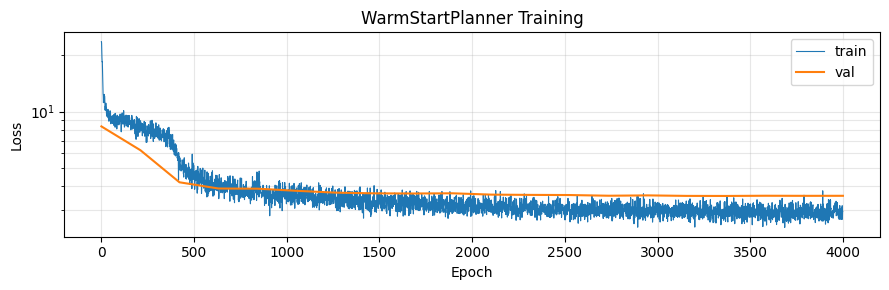

Model saved: models/wsp_general_0807_v1.pt


In [17]:
# ---------- WarmStartPlanner SSL Training ----------
# Full dataset - 08/07
print("Starting training...")
    
model_general_0807_v1, history_general_0807_v1 = train(
    # Paths
    train_dataset       = "data/dataset_general_0807_train.pt",
    val_dataset         = "data/dataset_general_0807_val.pt",
        
    # Configuration
    T                   = 50,
    C                   = 10,
        
    # Pre-trained encoders
    env_encoder_path    = "data/env_encoder_0807.pt",
    state_encoder_path  = "data/state_encoder_0807.pt",
    freeze_encoders     = True,
        
    # Parameters
    n_epochs            = 4000,
    batch_size          = 128,
    lr                  = 5e-4,
        
    # Loss weights
    w_coll              = 100.0,
    w_joints            = 1.0,
    w_smooth            = 2.0,
    w_spacing           = 2.0,
    w_explore           = 5.0,
        
    # Collision parameters
    explore_threshold   = 0.5,
    collision_eps       = 0.10,
    dt                  = 0.1,
        
    # Monitoring and Hardware
    log_every           = 200,
    device              = "cuda",
    save_path           = "models/wsp_general_0807_v1.pt",
)

Starting training...
Loaded env encoder:   data/env_encoder_0807.pt
Loaded state encoder: data/state_encoder_0807.pt

Loss              Raw      Weight    Weighted
──────────────────────────────────────────────
coll           3.7849    350.0000   1324.7005
joints         0.0000      1.0000      0.0000
smooth         0.2016      1.0000      0.2016
spacing        0.0000      2.0000      0.0000
explore        0.3164      5.0000      1.5820



Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Epoch   200 | lr=4.97e-04 | train=28.0341  coll=25.4087  joints=1.5528  smooth=0.8127  spacing=0.2599  explore=0.0000  val=29.1824
Epoch   400 | lr=4.88e-04 | train=14.4568  coll=12.9225  joints=0.0803  smooth=1.2215  spacing=0.2325  explore=0.0000  val=14.5581
Epoch   600 | lr=4.73e-04 | train=12.1863  coll=10.6985  joints=0.0381  smooth=1.2949  spacing=0.1549  explore=0.0000  val=12.7703
Epoch   800 | lr=4.52e-04 | train=10.8748  coll=9.5584  joints=0.0263  smooth=1.1681  spacing=0.1219  explore=0.0000  val=11.8331
Epoch  1000 | lr=4.27e-04 | train=9.2003  coll=7.9514  joints=0.0244  smooth=1.0821  spacing=0.1424  explore=0.0000  val=11.3373
Epoch  1200 | lr=3.97e-04 | train=9.9999  coll=8.6268  joints=0.0055  smooth=1.2285  spacing=0.1390  explore=0.0000  val=11.4592
Epoch  1400 | lr=3.64e-04 | train=9.3775  coll=8.0719  joints=0.0016  smooth=1.1589  spacing=0.1452  explore=0.0000  val=11.7877
Epoch  1600 | lr=3.28e-04 | train=9.3923  coll=8.0907  joints=0.0020  smooth=1.1506  spaci

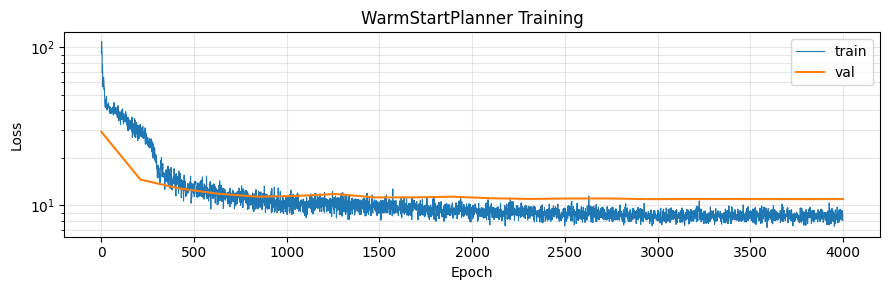

Model saved: models/wsp_general_0907_v1.pt


In [3]:
# ---------- WarmStartPlanner SSL Training ----------
# Full dataset - 09/07
print("Starting training...")
    
model_general_0907_v1, history_general_0907_v1 = train(
    # Paths
    train_dataset       = "data/dataset_general_0807_train.pt",
    val_dataset         = "data/dataset_general_0807_val.pt",
        
    # Configuration
    T                   = 50,
    C                   = 10,
        
    # Pre-trained encoders
    env_encoder_path    = "data/env_encoder_0807.pt",
    state_encoder_path  = "data/state_encoder_0807.pt",
    freeze_encoders     = True,
        
    # Parameters
    n_epochs            = 4000,
    batch_size          = 128,
    lr                  = 5e-4,
        
    # Loss weights
    w_coll              = 350.0,
    w_joints            = 1.0,
    w_smooth            = 1.0,
    w_spacing           = 2.0,
    w_explore           = 5.0,
        
    # Collision parameters
    explore_threshold   = 0.5,
    collision_eps       = 0.15,
    dt                  = 0.1,
        
    # Monitoring and Hardware
    log_every           = 200,
    device              = "cuda",
    save_path           = "models/wsp_general_0907_v1.pt",
)

Starting training...
Loaded env encoder:   data/env_encoder_0807.pt
Loaded state encoder: data/state_encoder_0807.pt

Loss              Raw      Weight    Weighted
──────────────────────────────────────────────
coll           3.7849    350.0000   1324.7005
joints         0.0000      1.0000      0.0000
smooth         0.2016      1.0000      0.2016
spacing        0.0000      2.0000      0.0000
explore        0.3164      5.0000      1.5820



Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Epoch   200 | lr=4.97e-04 | train=20.5502  coll=18.4022  joints=0.3964  smooth=1.3038  spacing=0.4479  explore=0.0000  val=21.0524
Epoch   400 | lr=4.88e-04 | train=12.5230  coll=11.1373  joints=0.0596  smooth=1.1497  spacing=0.1753  explore=0.0011  val=12.8494
Epoch   600 | lr=4.73e-04 | train=12.1113  coll=10.7950  joints=0.0003  smooth=1.1515  spacing=0.1644  explore=0.0000  val=11.5041
Epoch   800 | lr=4.52e-04 | train=11.3861  coll=10.0681  joints=0.0179  smooth=1.1303  spacing=0.1698  explore=0.0000  val=11.7005
Epoch  1000 | lr=4.27e-04 | train=12.3017  coll=11.0885  joints=0.0041  smooth=1.0596  spacing=0.1495  explore=0.0000  val=11.1809
Epoch  1200 | lr=3.97e-04 | train=9.5487  coll=8.3649  joints=0.0027  smooth=1.0407  spacing=0.1403  explore=0.0000  val=11.1699
Epoch  1400 | lr=3.64e-04 | train=9.5400  coll=8.3608  joints=0.0053  smooth=1.0270  spacing=0.1469  explore=0.0000  val=10.7611
Epoch  1600 | lr=3.28e-04 | train=8.0868  coll=6.9143  joints=0.0171  smooth=1.0160  sp

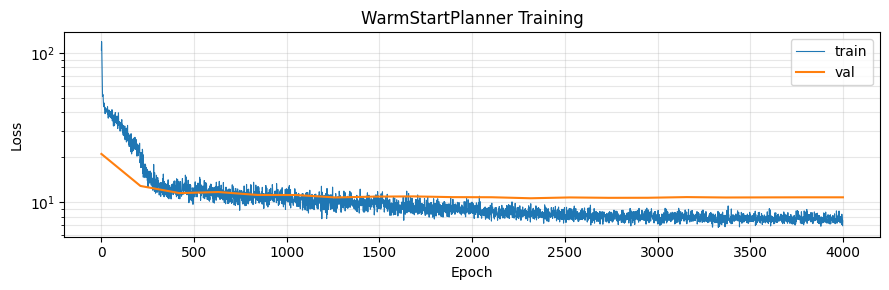

Model saved: models/wsp_general_0907_v2.pt


In [7]:
# ---------- WarmStartPlanner SSL Training ----------
# Full dataset - 09/07
print("Starting training...")
    
model_general_0907_v2, history_general_0907_v2 = train(
    # Paths
    train_dataset       = "data/dataset_general_0807_train.pt",
    val_dataset         = "data/dataset_general_0807_val.pt",
        
    # Configuration
    T                   = 50,
    C                   = 10,
        
    # Pre-trained encoders
    env_encoder_path    = "data/env_encoder_0807.pt",
    state_encoder_path  = "data/state_encoder_0807.pt",
    freeze_encoders     = False,
        
    # Parameters
    n_epochs            = 4000,
    batch_size          = 128,
    lr                  = 5e-4,
        
    # Loss weights
    w_coll              = 350.0,
    w_joints            = 1.0,
    w_smooth            = 1.0,
    w_spacing           = 2.0,
    w_explore           = 5.0,
        
    # Collision parameters
    explore_threshold   = 0.5,
    collision_eps       = 0.15,
    dt                  = 0.1,
        
    # Monitoring and Hardware
    log_every           = 200,
    device              = "cuda",
    save_path           = "models/wsp_general_0907_v2.pt",
)

In [3]:
# ---------- Trajectory Visualization ----------
print("Loading model and dataset...")

# Load the model
model_general = torch.load("models/wsp_general_0907_v1.pt", weights_only=False)
    
# Launch the visualizator
browse_trajectories(
    model     = model_general,
    dataset   = "data/dataset_general_0807_test.pt",
    save_name = "wsp_working_0907_v1"
)

Loading model and dataset...
